In [1]:
# ============================================================================
# Learner support-request triage workflow (LangGraph)
# ----------------------------------------------------------------------------
# A request flows through: intake -> priority scoring -> routing -> one of five
# handler branches -> summary. Each step reads the shared AgentState dict and
# returns a partial update that LangGraph merges back into state.
# ============================================================================
import json
from typing import TypedDict, Literal,List, Dict, Union     # typing helpers; Literal pins allowed string values
from datetime import date
from langgraph.graph import StateGraph, START, END           # graph builder + the two sentinel nodes


Create function to pass user input if/when prompt

In [2]:
# ----------------------------------------------------------------------------
# Shared state object. Every node receives this and returns a subset of it.
# The Literal[...] annotations document the ONLY legal values for each field.
# ----------------------------------------------------------------------------
class AgentState(TypedDict):
    learner_name: str                                                                           # name of person submitting the issue
    email: str                                                                                  # Contact email
    category: Literal["technical","billing","course_content","general"]                        # Submitted request category
    message: str                                                                                # learner's request
    days_until_deadline: int                                                                    # Days before the learner's deadline
    is_paid_student: bool                                                                       # whether the learner is enrolled in a paid track
    priority_score: int                                                                         # numeric score calculated by the workflow
    priority: Literal["low","normal","urgent"]                                                 # human-readable priority
    route: Literal["urgent","technical","billing","learning_support","general"]                # selected branch
    assigned_team: str                                                                          # team responsible for follow-up
    status: str                                                                                 # current triage outcome
    response: str                                                                               # message prepared for the learner
    audit_log: list[str]
# ----------------------------------------------------------------------------
# Smoke test for state construction + JSON serialisation. Runs only when this
# file is executed directly, not when it is imported elsewhere.
# ----------------------------------------------------------------------------
# if __name__ == "__main__":
#     # Build a fully-populated state to confirm every field accepts its value...
#     user = AgentState(
#         learner_name="John Doe",
#         email="johndoe@outlook.com",
#         category="technical",
#         message="Hello World",
#         days_until_deadline=3,
#         is_paid_student=True,
#         priority_score=90,
#         priority="low",
#         route="urgent",
#         assigned_team="technical",
#         status="urgent",
#         response="urgent",
#         audit_log=[]
#     )
#     user_json = json.dumps(user)    # ...and confirm the state is JSON-serialisable
#     # print(user_json)
#     #
#     # print(user_json)

In [3]:
# ----------------------------------------------------------------------------
# NODE 1 - Intake. Pass the raw submission through unchanged, mark the request
# as received, and append the first audit-log entry.
# ----------------------------------------------------------------------------
def intake_node(state: AgentState) -> dict:
    print("intake_node")   #testing

    # read learner name, email, category, and message from input state

    learner_name = state.get("learner_name")
    email = state.get("email")
    category = state.get("category")
    message = state.get("message")

    log_entry = f"Request received for {learner_name}.\n"       # first line written to the audit trail
    audit_log = state.get("audit_log") or []                    # default to empty list if absent

    # Return only the fields this node is responsible for; LangGraph merges them in.
    return {
        "learner_name": learner_name,
        "email": email,
        "category": category,
        "message": message,
        "status": "Received\n",
        "audit_log": audit_log + [log_entry],       # append, never overwrite, the log
    }

Document your scoring rules here

In [4]:
# Reusable alias for the three legal priority levels (used as a type hint below).
PriorityType = Literal["low", "normal", "urgent"]
# ----------------------------------------------------------------------------
# NODE 2 - Priority scoring. Adds points for risk keywords, picks a base
# priority from deadline/category, then promotes one level if the score is high.
# ----------------------------------------------------------------------------
def calculate_priority_node(state: AgentState) -> dict:
    priority_score: int = state.get("priority_score") or 0
    days_until_deadline = state.get("days_until_deadline")
    route = state.get("route")
    message: str = state.get("message") or ""

    # Add 10 points for each risk phrase present in the learner's message.
    wordlist = ["blocked", "cannot submit", "charged twice", "deadline"]
    for word in wordlist:
        if word in message.lower():
            priority_score += 10

    # Pick the BASE priority from deadline first, then category.
    # Enforce the type hint on our target variable
    new_priority: PriorityType
    if days_until_deadline is not None and days_until_deadline <= 1:
        new_priority = "urgent"
    elif route == "technical":
        new_priority = "normal"
    else:
        new_priority = "low"

    # Promotion rule: if not already urgent but the score is high, bump one level.
    prioritymap: list[PriorityType] = ["low", "normal", "urgent"]
    count = prioritymap.index(new_priority)
    if new_priority != "urgent" and priority_score >= 90:
        count += 1
        new_priority = prioritymap[count]

    return {
        "priority": new_priority,
        "priority_score": priority_score,
    }


In [5]:
# ----------------------------------------------------------------------------
# NODE 3 - Routing wrapper. The graph runs THIS as a step. It calls the pure
# decision function below and PERSISTS the result into state["route"], so the
# branch nodes downstream can read the real branch (not the stale initial value).
# A node must return a dict, which is why the wrapper exists.
# ----------------------------------------------------------------------------
# Real node: persists the routing decision into state so branch nodes see it
def route_request_node(state: AgentState) -> dict:
    return {"route": route_request(state)}

# ----------------------------------------------------------------------------
# Pure routing decision. Returns a branch NAME (a string), not a state update.
# Used by add_conditional_edges to choose which handler runs next.
# Precedence: urgent priority overrides everything, else follow category,
# else fall back to general.
# ----------------------------------------------------------------------------
# Pure routing function used by the conditional edge
def route_request(state: AgentState) -> Literal["urgent","technical","billing","learning_support","general"]:
    priority = state.get("priority")
    category = state.get("category")

    if priority == "urgent":
        return "urgent"
    elif category == "technical":
        return "technical"
    elif category == "billing":
        return "billing"
    elif category == "learning_support":
        return "learning_support"
    else:
        return "general"

In [6]:
# ----------------------------------------------------------------------------
# NODES 4a-4e - Branch handlers. All five are intentionally identical: they
# stamp the assigned team, status, an escalation log line, and a confirmation
# message, all derived from the route chosen in NODE 3.
# ----------------------------------------------------------------------------
def urgent_node(state: AgentState) -> dict:
    route = state.get("route")      # route was written by route_request_node

    return {
        "assigned_team": f"'{route}'_Team",
        "status": f"'{route}' Request Received",
        "audit_log": state.get("audit_log", []) + [
            f"'{route}' escalation triggered for request submitted"
        ],
        "message": f"The priority '{route}' was executed",
    }

def technical_node(state: AgentState) -> dict:
    route = state.get("route")

    return {
        "assigned_team": f"'{route}'_Team",
        "status": f"'{route}' Request Received",
        "audit_log": state.get("audit_log", []) + [
            f"'{route}' escalation triggered for request submitted"
        ],
        "message": f"The priority '{route}' was executed",
    }

def billing_node(state: AgentState) -> dict:
    route = state.get("route")

    return {
        "assigned_team": f"'{route}'_Team",
        "status": f"'{route}' Request Received",
        "audit_log": state.get("audit_log", []) + [
            f"'{route}' escalation triggered for request submitted"
        ],
        "message": f"The priority '{route}' was executed",
    }

def learning_support_node(state: AgentState) -> dict:
    route = state.get("route")

    return {
        "assigned_team": f"'{route}'_Team",
        "status": f"'{route}' Request Received",
        "audit_log": state.get("audit_log", []) + [
            f"'{route}' escalation triggered for request submitted"
        ],
        "message": f"The priority '{route}' was executed",
    }

def general_node(state: AgentState) -> dict:
    route = state.get("route")

    return {
        "assigned_team": f"'{route}'_Team",
        "status": f"'{route}' Request Received",
        "audit_log": state.get("audit_log", []) + [
            f"'{route}' escalation triggered for request submitted"
        ],
        "message": f"The priority '{route}' was executed",
    }

In [7]:
# ----------------------------------------------------------------------------
# NODE 5 - Summary. Composes the final learner-facing response and writes a
# closing audit-log line. Urgent requests keep their status; others -> "triaged".
# ----------------------------------------------------------------------------
def summary_node(state: AgentState) -> dict:
    route = state.get("route")
    priority = state.get("priority", "normal")
    assigned_team = state.get("assigned_team", "General_Team")
    current_status = state.get("status", "")

   # Keep the urgent status as-is; everything else is marked triaged.
    final_status = current_status if priority == "urgent" else "triaged"

    # Human-readable confirmation sent back to the learner.
    final_response = (
        f"Your {route} request has been {final_status}. "
        f"It has been assigned to {assigned_team} with {priority} priority."
    )

    return {
        "status": final_status,
        "response": final_response,
        "audit_log": state.get("audit_log", []) + [
            f"Request '{route}' finalised as '{final_status}' and assigned to {assigned_team}."
        ],
    }

In [8]:
# ============================================================================
# GRAPH ASSEMBLY
# ============================================================================
graph = StateGraph(AgentState)      # state schema the graph operates on

# Register every node under a string name used by the edges below.
graph.add_node("intake_node", intake_node)
graph.add_node("calculate_priority_node", calculate_priority_node)
graph.add_node("route_request", route_request_node)  # NOTE: the wrapper (returns dict), not route_request
graph.add_node("urgent_node", urgent_node)
graph.add_node("technical_node", technical_node)
graph.add_node("billing_node", billing_node)
graph.add_node("learning_support_node", learning_support_node)
graph.add_node("general_node", general_node)
graph.add_node("summary_node", summary_node)

# Linear flow up to the fork.
graph.add_edge(START,"intake_node")
graph.add_edge("intake_node","calculate_priority_node")
graph.add_edge("calculate_priority_node", "route_request")

# Conditional fork: route_request (the pure function) returns a branch name,
# which is mapped here to the handler node that should run next.
graph.add_conditional_edges("route_request",route_request,{
     "urgent":"urgent_node",
     "technical":"technical_node",
     "billing":"billing_node",
     "learning_support":"learning_support_node",
     "general":"general_node"
})

# All branches converge back into the summary step.
graph.add_edge("urgent_node","summary_node")
graph.add_edge("technical_node","summary_node")
graph.add_edge("billing_node","summary_node")
graph.add_edge("learning_support_node","summary_node")
graph.add_edge("general_node","summary_node")
graph.add_edge("summary_node",END)       # summary is the final step


In [9]:
workflow = graph.compile()          # validate wiring and produce the runnable workflow

# Print the graph as Mermaid (the diagram you can paste into a renderer).
print(workflow.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	intake_node(intake_node)
	calculate_priority_node(calculate_priority_node)
	route_request(route_request)
	urgent_node(urgent_node)
	technical_node(technical_node)
	billing_node(billing_node)
	learning_support_node(learning_support_node)
	general_node(general_node)
	summary_node(summary_node)
	__end__([<p>__end__</p>]):::last
	__start__ --> intake_node;
	billing_node --> summary_node;
	calculate_priority_node --> route_request;
	general_node --> summary_node;
	intake_node --> calculate_priority_node;
	learning_support_node --> summary_node;
	route_request -. &nbsp;billing&nbsp; .-> billing_node;
	route_request -. &nbsp;general&nbsp; .-> general_node;
	route_request -. &nbsp;learning_support&nbsp; .-> learning_support_node;
	route_request -. &nbsp;technical&nbsp; .-> technical_node;
	route_request -. &nbsp;urgent&nbsp; .-> urgent_node;
	technical_node --> summary_node;
	urgent_node --> summar

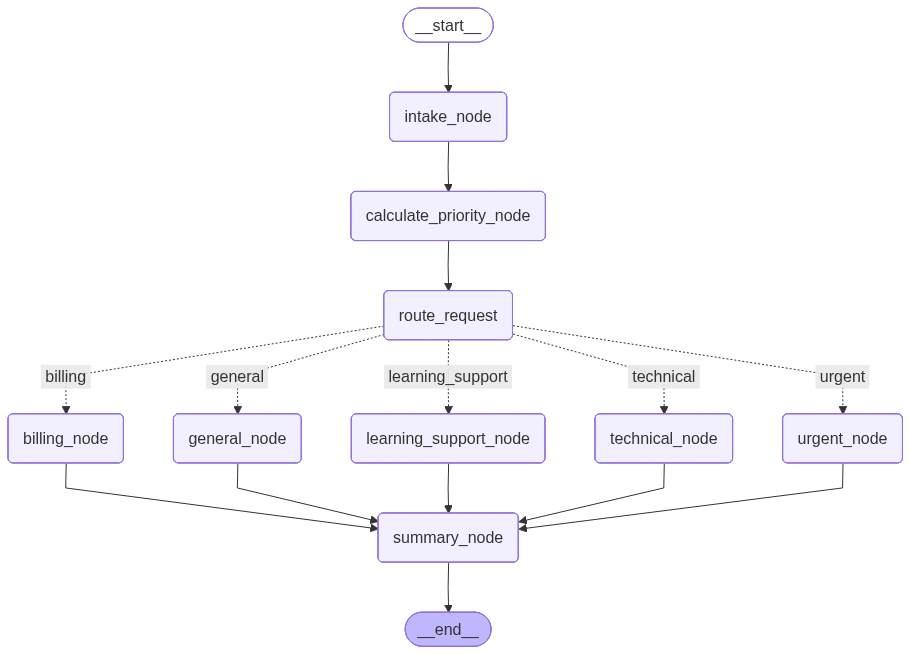

In [10]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [11]:
# ----------------------------------------------------------------------------
# Example invocation. Pre-seed every field; nodes overwrite what they compute.
# ----------------------------------------------------------------------------
# initState = {
#     "learner_name": "John Doe",
#     "email": "johndoe@outlook.com",
#     "category": "technical",
#     "message": "I cannot submit my assignment and the deadline is tomorrow",
#     "days_until_deadline": 1,
#     "is_paid_student": True,
#     "priority_score": 0,
#     "priority": "normal",
#     "route": "general",
#     "assigned_team": "",
#     "status": "",
#     "response": "",
#     "audit_log": []
# }

initState = {
    "learner_name": "John Doe",
    "email": "johndoe@outlook.com",
    "category": "technical",
    "message": "I cannot submit my assignment and the deadline is tomorrow",
    "days_until_deadline": 1,
    "is_paid_student": True,
    "priority_score": 0,
    "priority": "normal",
    "route": "general",
    "assigned_team": "",
    "status": "",
    "response": "",
    "audit_log": []
}

In [12]:
result = workflow.invoke(initState)         # run the whole graph start to end

# Print every field in the final state on its own line, in a readable layout.
print("\n===== FINAL STATE =====")
for key, value in result.items():
    if key == "audit_log":
        # The audit log is a list; print each entry on its own indented line.
        print(f"{key}:")
        for i, entry in enumerate(value, start=1):
            print(f"    {i}. {repr(entry)}")
    else:
        print(f"{key}: {value!r}")
print("=======================")

intake_node

===== FINAL STATE =====
learner_name: 'John Doe'
email: 'johndoe@outlook.com'
category: 'technical'
message: "The priority 'urgent' was executed"
days_until_deadline: 1
is_paid_student: True
priority_score: 20
priority: 'urgent'
route: 'urgent'
assigned_team: "'urgent'_Team"
status: "'urgent' Request Received"
response: "Your urgent request has been 'urgent' Request Received. It has been assigned to 'urgent'_Team with urgent priority."
audit_log:
    1. 'Request received for John Doe.\n'
    2. "'urgent' escalation triggered for request submitted"
    3. "Request 'urgent' finalised as ''urgent' Request Received' and assigned to 'urgent'_Team."


In [13]:
"""
Required test invocations for the learner-support triage workflow.

Imports the compiled `workflow` from learner_support_triage.py (unchanged logic)
and runs it once per expected route, printing the request, key outputs, and the
full audit log, plus assertions proving the routing worked.

Assigned-team names follow THIS design's format: f"'{route}'_Team"
(e.g. "'urgent'_Team"), not the example's "on_call_instructor".
"""

# ---------------------------------------------------------------------------
# Helper: every AgentState field seeded with sensible defaults, like the
# challenge example. Individual tests override only what they need.
# ---------------------------------------------------------------------------
def base_request(**overrides):
    request = {
        "learner_name": "John Doe",
        "email": "johndoe@outlook.com",
        "category": "general",
        "message": "",
        "days_until_deadline": 7,
        "is_paid_student": True,
        "priority_score": 0,
        "priority": "normal",
        "route": "general",
        "assigned_team": "",
        "status": "",
        "response": "",
        "audit_log": [],
    }
    request.update(overrides)
    return request


def show(test_no, title, request, result):
    print("\n" + "=" * 70)
    print(f"TEST {test_no}: {title}")
    print("=" * 70)
    print("--- INITIAL REQUEST ---")
    print(f"  learner_name : {request['learner_name']}")
    print(f"  category     : {request['category']}")
    print(f"  message      : {request['message']!r}")
    print(f"  deadline(d)  : {request['days_until_deadline']}")
    print("--- FINAL OUTPUT ---")
    print(f"  route        : {result['route']}")
    print(f"  priority     : {result['priority']}")
    print(f"  assigned_team: {result['assigned_team']}")
    print(f"  status       : {result['status']}")
    print(f"  response     : {result['response']}")
    print("--- AUDIT LOG ---")
    for i, entry in enumerate(result["audit_log"], start=1):
        print(f"  {i}. {entry!r}")


# ===========================================================================
# TEST 1 - Technical request, deadline today -> urgent
# ===========================================================================
req1 = base_request(
    category="technical",
    message="I cannot submit my assignment and the deadline is today",
    days_until_deadline=0,
)
res1 = workflow.invoke(req1)

# Print every field in the final state on its own line.
print("===== TEST 1: Technical + deadline today =====")
for key, value in res1.items():
    if key == "audit_log":
        print(f"{key}:")
        for i, entry in enumerate(value, start=1):
            print(f"    {i}. {entry!r}")
    else:
        print(f"{key}: {value!r}")
print("==============================================")


# ===========================================================================
# TEST 2 - Technical request, several days left -> technical
# ===========================================================================
req2 = base_request(
    category="technical",
    message="My IDE keeps crashing when I run the notebook",
    days_until_deadline=6,
)
res2 = workflow.invoke(req2)

# Print every field in the final state on its own line.
print("===== TEST 2: Technical + days remaining =====")
for key, value in res2.items():
    if key == "audit_log":
        print(f"{key}:")
        for i, entry in enumerate(value, start=1):
            print(f"    {i}. {entry!r}")
    else:
        print(f"{key}: {value!r}")
print("==============================================")


# ===========================================================================
# TEST 3 - Non-urgent payment/refund -> billing
# ===========================================================================
req3 = base_request(
    category="billing",
    message="I would like a refund for last month's subscription",
    days_until_deadline=10,
)
res3 = workflow.invoke(req3)

print("===== TEST 3: Non-urgent billing =====")
for key, value in res3.items():
    if key == "audit_log":
        print(f"{key}:")
        for i, entry in enumerate(value, start=1):
            print(f"    {i}. {entry!r}")
    else:
        print(f"{key}: {value!r}")
print("======================================")


# ===========================================================================
# TEST 4 - Non-urgent assignment/lesson question -> learning_support
# NOTE: route_request keys off category == "learning_support", so the input
# sets that category directly (see reflection on the vocabulary mismatch).
# ===========================================================================
req4 = base_request(
    category="learning_support",
    message="Could you clarify the difference between the two algorithms in lesson 4?",
    days_until_deadline=12,
)
res4 = workflow.invoke(req4)

print("===== TEST 4: Non-urgent lesson question =====")
for key, value in res4.items():
    if key == "audit_log":
        print(f"{key}:")
        for i, entry in enumerate(value, start=1):
            print(f"    {i}. {entry!r}")
    else:
        print(f"{key}: {value!r}")
print("==============================================")


# ===========================================================================
# TEST 5 - Non-urgent general request -> general
# ===========================================================================
req5 = base_request(
    category="general",
    message="How do I update the email address on my account?",
    days_until_deadline=15,
)
res5 = workflow.invoke(req5)

print("===== TEST 5: Non-urgent general =====")
for key, value in res5.items():
    if key == "audit_log":
        print(f"{key}:")
        for i, entry in enumerate(value, start=1):
            print(f"    {i}. {entry!r}")
    else:
        print(f"{key}: {value!r}")
print("======================================")

intake_node
===== TEST 1: Technical + deadline today =====
learner_name: 'John Doe'
email: 'johndoe@outlook.com'
category: 'technical'
message: "The priority 'urgent' was executed"
days_until_deadline: 0
is_paid_student: True
priority_score: 20
priority: 'urgent'
route: 'urgent'
assigned_team: "'urgent'_Team"
status: "'urgent' Request Received"
response: "Your urgent request has been 'urgent' Request Received. It has been assigned to 'urgent'_Team with urgent priority."
audit_log:
    1. 'Request received for John Doe.\n'
    2. "'urgent' escalation triggered for request submitted"
    3. "Request 'urgent' finalised as ''urgent' Request Received' and assigned to 'urgent'_Team."
intake_node
===== TEST 2: Technical + days remaining =====
learner_name: 'John Doe'
email: 'johndoe@outlook.com'
category: 'technical'
message: "The priority 'technical' was executed"
days_until_deadline: 6
is_paid_student: True
priority_score: 0
priority: 'low'
route: 'technical'
assigned_team: "'technical'_Tea